In [2]:
# Compara o resultado da avalição dos modelos Bert.
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# Ler planilha Fin_Bert
df_fin_bert = pd.read_csv("/home/paulo/projeto_tech_05/complaints_with_sentiment.csv")
df_fin_bert.info()
df_fin_bert.head()

<class 'pandas.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 5 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   product                  162421 non-null  str    
 1   narrative                162411 non-null  str    
 2   clean_narrative          162411 non-null  str    
 3   sentiment_FinancialBERT  162421 non-null  str    
 4   score                    162421 non-null  float64
dtypes: float64(1), str(4)
memory usage: 171.6 MB


,product,narrative,clean_narrative,sentiment_FinancialBERT,score
0,credit_card,purchase order day shipping amount receive pro...,purchas ord day ship amount receiv produc week...,neutral,0.998380
1,credit_card,forwarded message date tue subject please inve...,forward mess dat tue subject pleas investig co...,neutral,0.997814
2,retail_banking,forwarded message cc sent friday pdt subject f...,forward mess cc sent friday pdt subject fin le...,neutral,0.985487
3,credit_reporting,payment history missing credit report speciali...,pay hist miss credit report spec loan serv sl ...,neutral,0.995491
4,credit_reporting,payment history missing credit report made mis...,pay hist miss credit report mad mistak put acc...,neutral,0.995610


In [15]:
# Ler planilha RoBERTa
df_RoBERTa = pd.read_csv("/home/paulo/projeto_tech_05/complaints_sentiment_RoBERTa.csv")
df_RoBERTa.info()
df_RoBERTa.head()

<class 'pandas.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   product          162421 non-null  str    
 1   narrative        162411 non-null  str    
 2   stem_narrative   162411 non-null  str    
 3   sentiment_value  162421 non-null  str    
 4   score            162421 non-null  float64
dtypes: float64(1), str(4)
memory usage: 171.6 MB


,product,narrative,stem_narrative,sentiment_value,score
0,credit_card,purchase order day shipping amount receive pro...,purchas ord day ship amount receiv produc week...,neutral,0.550079
1,credit_card,forwarded message date tue subject please inve...,forward mess dat tue subject pleas investig co...,negative,0.494491
2,retail_banking,forwarded message cc sent friday pdt subject f...,forward mess cc sent friday pdt subject fin le...,neutral,0.717251
3,credit_reporting,payment history missing credit report speciali...,pay hist miss credit report spec loan serv sl ...,neutral,0.553077
4,credit_reporting,payment history missing credit report made mis...,pay hist miss credit report mad mistak put acc...,neutral,0.578120


In [19]:
## Distribuição geral de sentimentos
sentimento_ttl_finbert=df_fin_bert["sentiment_FinancialBERT"].value_counts(normalize=False)
print(sentimento_ttl_finbert)

sentiment_FinancialBERT
neutral     158447
negative      3195
positive       779
Name: count, dtype: int64


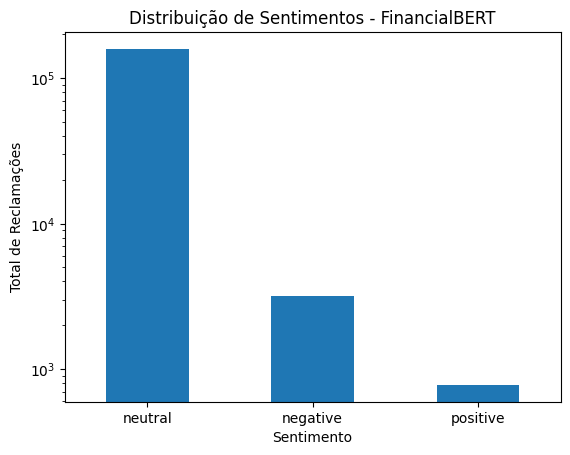

In [22]:

# plotar resultados usando escala logaritimica
sentimento_df_finbert=pd.DataFrame({"sentimento":sentimento_ttl_finbert.index,
                                    "total":sentimento_ttl_finbert.values})
sentimento_df_finbert.plot(x="sentimento", 
                           y="total", 
                           kind="bar", 
                           legend=False)
plt.title("Distribuição de Sentimentos - FinancialBERT")
plt.xlabel("Sentimento")
plt.ylabel("Total de Reclamações")
plt.yscale("log")
plt.xticks(rotation=0)
plt.show() 

In [23]:
## Distribuição geral de sentimentos
sentimento_ttl_roberta=df_RoBERTa["sentiment_value"].value_counts(normalize=False)
#sentimento_prop=df_fin_bert["sentiment_FinancialBERT"].value_counts(normalize=True)

print(sentimento_ttl_roberta)

sentiment_value
neutral     118019
negative     44237
positive       165
Name: count, dtype: int64


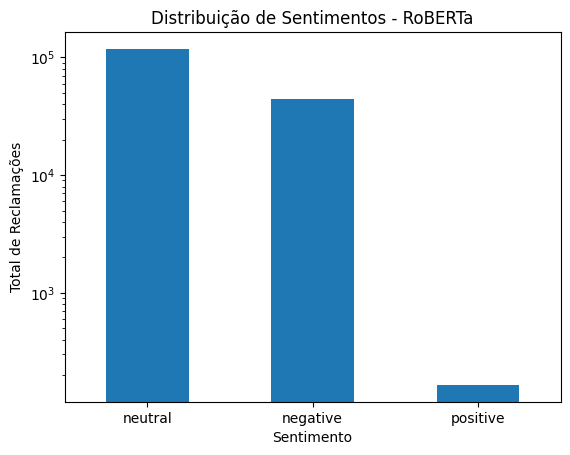

In [24]:

# plotar resultados usando escala logaritimica
sentimento_df_roberta=pd.DataFrame({"sentimento":sentimento_ttl_roberta.index,
                                    "total":sentimento_ttl_roberta.values})
sentimento_df_roberta.plot(x="sentimento", 
                           y="total", 
                           kind="bar", 
                           legend=False)
plt.title("Distribuição de Sentimentos - RoBERTa")
plt.xlabel("Sentimento")
plt.ylabel("Total de Reclamações")
plt.yscale("log")
plt.xticks(rotation=0)
plt.show() 

In [32]:
# Merge dos dataframes pelo indice para comparação dos resultados
from operator import index
df_comparacao = pd.merge(df_fin_bert, 
                         df_RoBERTa, 
                         left_index=True, 
                         right_index=True, 
                         suffixes=('_finbert', '_roberta'))
df_comparacao.info()
df_comparacao.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   product_finbert          162421 non-null  str    
 1   narrative_finbert        162411 non-null  str    
 2   clean_narrative          162411 non-null  str    
 3   sentiment_FinancialBERT  162421 non-null  str    
 4   score_finbert            162421 non-null  float64
 5   product_roberta          162421 non-null  str    
 6   narrative_roberta        162411 non-null  str    
 7   stem_narrative           162411 non-null  str    
 8   sentiment_value          162421 non-null  str    
 9   score_roberta            162421 non-null  float64
dtypes: float64(2), str(8)
memory usage: 343.2 MB


,product_finbert,narrative_finbert,clean_narrative,sentiment_FinancialBERT,score_finbert,product_roberta,narrative_roberta,stem_narrative,sentiment_value,score_roberta
0,credit_card,purchase order day shipping amount receive pro...,purchas ord day ship amount receiv produc week...,neutral,0.998380,credit_card,purchase order day shipping amount receive pro...,purchas ord day ship amount receiv produc week...,neutral,0.550079
1,credit_card,forwarded message date tue subject please inve...,forward mess dat tue subject pleas investig co...,neutral,0.997814,credit_card,forwarded message date tue subject please inve...,forward mess dat tue subject pleas investig co...,negative,0.494491
2,retail_banking,forwarded message cc sent friday pdt subject f...,forward mess cc sent friday pdt subject fin le...,neutral,0.985487,retail_banking,forwarded message cc sent friday pdt subject f...,forward mess cc sent friday pdt subject fin le...,neutral,0.717251
